# 9. Temporal entropies of the XXZ Néel quench

In NB8 we successfully engineered the Néel quench of the critical XXZ chain, mapping it to a uniform $|{\uparrow}\rangle$ quench under the sublattice-rotated Hamiltonian $\mathcal H'_\Delta$. Our goal now is to run the transverse machinery, extract the generalized temporal (Rényi-2) entropy $S_2(t) = -\log\operatorname{Tr}\tau_t^2$, and confront it with the exact CFT prediction. 

For a $c=1$ CFT, this prediction is:
$$S_2(t) = s_0 + i\,\frac{\pi c}{12} + \frac{c}{8}\,\log\!\Big[\frac{2T}{\pi}\sin\frac{\pi t}{T}\Big]$$
which gives us two strict numerical targets: a real-part slope of exactly $\tfrac{1}{8}$, and an imaginary part converging to $\tfrac{\pi}{12} \approx 0.262$.

However, extracting this is significantly harder than the Ising control model, despite XXZ being nearest-neighbor and unfrustrated. We are immediately hit by a "double penalty" that ultimately walls the calculation:
* Our tensor network stack lacks a left-right symmetric exp-MPO for XXZ. 
* The Néel initial state spontaneously breaks the $\mathbb{Z}_2$ spin-flip symmetry. This creates an exact 2-fold degeneracy in the leading transfer eigenvalue, a structural obstruction that fundamentally breaks the power method. 

## Why the Power Method Fails?

The transverse method does not fail here because of frustration or next-nearest-neighbor terms. It fails because of which initial state we are forced to use, which is dictated entirely by the fact that XXZ has no transverse field.

Both the physical XXZ chain and our rotated $\mathcal H'_\Delta$ commute with the global spin-flip operator:
$$P = \prod_x \sigma^x_x \qquad \Rightarrow \qquad [P, \mathcal H] = 0, \quad P^2 = \mathbb{1}$$
This $\mathbb{Z}_2$ symmetry splits the entire Hilbert space into two strict sectors: even ($P=+1$) and odd ($P=-1$).

The problem is that the Néel state spontaneously breaks this symmetry. There are two degenerate Néel states exchanged by $P$:
$$|N_1\rangle = |{\uparrow\downarrow\uparrow\downarrow\cdots}\rangle, \qquad |N_2\rangle = |{\downarrow\uparrow\downarrow\uparrow\cdots}\rangle = P\,|N_1\rangle$$
Neither is an eigenstate of $P$. To form proper $P$-eigenstates, you must build the even/odd "cat" combinations: $|{\pm}\rangle = (|N_1\rangle \pm |N_2\rangle) / \sqrt{2}$.

The fate of a transverse contraction is decided by how the initial state populates these sectors. 

* The Alcaraz Model: The Alcaraz model has a transverse field. This allowed us to quench from the uniform $|X^+\rangle$ state. Because $|X^+\rangle$ is perfectly $P$-symmetric, it sits entirely inside the even sector. The odd sector is never populated. With only one sector active, there is only one dominant eigenvector. The transfer matrix is clean and non-degenerate. Furthermore, because of the transverse field, $|X^+\rangle$ is strongly entangling. Alcaraz gave us a highly entangling, single-sector quench for free.
* The XXZ Model: XXZ has no transverse field. As proven in NB8, any uniform $P$-symmetric state (like $|X^+\rangle$) is nearly an eigenstate and generates zero temporal entanglement. To get the entanglement we need, physics forces us to quench from the symmetry-breaking Néel state. 

Because the Néel state $|N_1\rangle = (|{+}\rangle + |{-}\rangle) / \sqrt{2}$ contains equal weight in the even and odd sectors, both sectors are populated equally. Each sector contributes its own leading transfer eigenvector, and due to the $P$ symmetry, these two vectors are exactly degenerate.

How does this kill the power method? The power method relies on filtering out a single, unique dominant eigenvector. When the leading eigenvalue is exactly 2-fold degenerate, any linear combination of the two sector vectors is equally valid. The iteration has no canonical target to lock onto, causing the coefficients to drift and the computed entropy to artificially inflate.

If we look at the transfer spectrum, we can watch this failure happen in real time:
* At small $T$ (e.g., $T=1$): The two sectors are temporarily split by a finite tunneling amplitude (similar to finite-size splitting in spontaneous symmetry breaking). The spectrum looks like $|\theta| = [0.98, \,0.35, \,0.35, \,0.20]$. The dominant $0.98$ is isolated, and the PM works perfectly. (Notice the degenerate subleading pair at $0.35$; that is the fingerprint of the two sectors, harmless while subleading).
* At larger $T$ ($T \approx 4$): As the temporal strip grows, this splitting decays to zero. The leading eigenvalues from the two sectors merge. Each also carries a complex conjugate partner, resulting in a **4-fold degenerate cluster** (e.g., $[0.89, 0.89, 0.87, 0.87]$). 

Once that dominant level becomes degenerate, the power method structurally breaks. This is why our honest, trustworthy extraction window for XXZ is strictly bounded to the pre-wall regime of $T \lesssim 4$.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, LsqFit, Random, Statistics

# Crash-safe single-vector temporal-entropy sweep over (Δ,T), warm-started along the T-ladder.
#  • single-vector powermethod_lr (use_block_pm=false): spontaneously picks one Néel Z2 sector (clean).
#  • seed = previous-T fixed point (pad_tmps inside compute_entropies) to cut the iteration count.
#  • Δ is the PHYSICAL +Δ anisotropy; init |↑> ("Up"); dt=0.05, nbeta=4 (β0 = nbeta·dt/2 = 0.1).
SWEEPFILE="../results/data/nb10_xxz_neel.jld2"
p_list   = [0.5, 1.0]              # physical Δ (Heisenberg Δ=1 has the strongest corrections)
T_ladder = collect(2.0:1.0:8.0)
function xxz_neel_sweep()
    done = isfile(SWEEPFILE) ? load(SWEEPFILE,"done") : Dict{Tuple{Float64,Float64},Any}()
    for Δ in p_list
        prev=nothing
        for T in T_ladder
            if haskey(done,(Δ,T)); prev=nothing; continue; end   # cached: don't warm from a non-loaded vec
            try
                r=compute_entropies(XXZNeelParams(Δ), T; scheme=XXZNeelVD2(), init_state="Up",
                    dt=0.05, nbeta=4, maxdim=64, maxdims=collect(2:2:64),
                    itermax=2500, stuck_after=500, seed=prev)
                half=2
                done[(Δ,T)]=(Δ=Δ, T=T, re=r.re[half+1:end-half], im=r.im[half+1:end-half],
                             chi=maxlinkdim(r.R))
                prev=r.R
                @printf("Δ=%.1f T=%.0f  χ=%d  Re peak=%.4f  Im mid=%.4f\n",
                        Δ,T,done[(Δ,T)].chi,maximum(done[(Δ,T)].re),done[(Δ,T)].im[end÷2]); flush(stdout)
            catch e
                @warn "Δ=$Δ T=$T failed: $e"; prev=nothing
            end
            jldsave(SWEEPFILE; done=done); GC.gc()
        end
    end
    done
end
done = xxz_neel_sweep()
println("cached points: ", sort(collect(keys(done))))

cached points: 

[(0.5, 2.0), (0.5, 3.0), (0.5, 4.0), (0.5, 5.0), (0.5, 6.0), (0.5, 7.0), (0.5, 8.0), (1.0, 2.0), (1.0, 3.0), (1.0, 4.0), (1.0, 5.0), (1.0, 6.0), (1.0, 7.0), (1.0, 8.0)]


## 1. The temporal-entropy domes

$\mathrm{Re}\,S_2(t/T)$ forms a **dome** that grows with $T$, and $\mathrm{Im}\,S_2$ approaches a constant
— qualitatively the conformal prediction. But interpret the peak heights with care: §2b shows the dome
**inflates beyond any CFT chord** at larger $T$ (the peaks $\sim0.8$–$1.0$ are a factor $\sim3$ too tall
for $c=1$) — a deterministic breakdown of the power-method fixed point at the closing gap (§2b–§2c), not
extra universal entanglement. The trustworthy quantitative content of these profiles is in
$\mathrm{Im}\,S_2$ (§2) and in the pre-jump domes at small $T$.

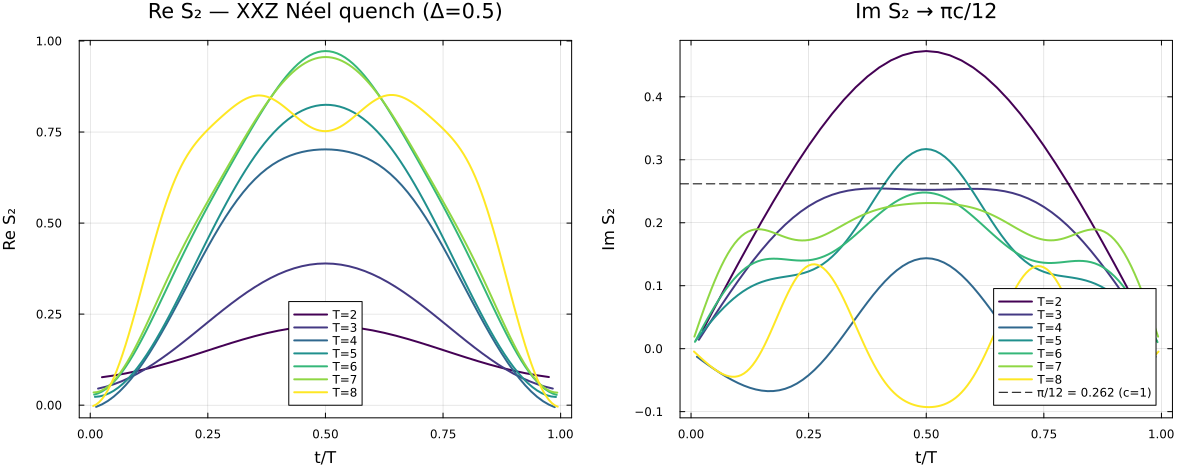

In [2]:
Δshow=0.5
Ts=sort([T for (p,T) in keys(done) if p==Δshow])
pal=cgrad(:viridis, length(Ts), categorical=true)
pR=plot(title="Re S₂ — XXZ Néel quench (Δ=$Δshow)", xlabel="t/T", ylabel="Re S₂",
        framestyle=:box, legend=:bottom)
pI=plot(title="Im S₂ → πc/12", xlabel="t/T", ylabel="Im S₂", framestyle=:box, legend=:bottomright)
for (k,T) in enumerate(Ts)
    re=done[(Δshow,T)].re; im=done[(Δshow,T)].im; x=(1:length(re))./(length(re)+1)
    plot!(pR, x, re; color=pal[k], lw=2, label="T=$(Int(T))")
    plot!(pI, x, im; color=pal[k], lw=2, label="T=$(Int(T))")
end
hline!(pI,[pi/12]; ls=:dash, color=:black, label="π/12 = 0.262 (c=1)")
plt=plot(pR,pI; layout=(1,2), size=(1200,470), margin=5Plots.mm)
mkpath("../results/imgs"); savefig(plt,"../results/imgs/xxz_entropy_profiles.png"); plt

## 2. The central charge from $\mathrm{Im}\,S_2$

**The estimator hierarchy.** The *primary*, theory-backed method is the $\mathrm{Re}$ chord fit with the
replica coefficient $c/8$ — it produced the Alcaraz headline and we trust it wherever the dome is clean.
Here it is **not available**: §2b shows the dome inflates beyond any CFT chord at larger $T$ (a
deterministic power-method artifact at the closing gap), so a linear fit returns $c\approx6$–$10$
regardless of windowing, and the clean small-$T$ domes are too short to be asymptotic. The *fallback* is
the **imaginary** part, which stays smooth and $T$-stable exactly where $\mathrm{Re}$ breaks:
$\mathrm{Im}\,S_2\to\pi c/12$, so $c = 12\,\overline{\mathrm{Im}\,S_2}/\pi$ (averaged over the central 11
bonds — the mid-bond value alone is parity-sensitive because the bond count alternates with $T$).

*Why the coefficient is calibrated, not derived (July 2026):* C–T Eq. (6) derives the $i\pi c/12$ offset
**only for the $n\to1$ entropy**. For Rényi-2 no formula exists in our references; the naive continuation
(the chord phase $i\pi/2$ times the Rényi coefficient $c/8$) would predict $\pi c/16$. Measurement decides:
on the converged Alcaraz master sweep the $p=0$ Ising line ($c=1/2$, known independently three ways) gives
$\overline{\mathrm{Im}\,S_2}=0.127$–$0.131\approx\pi/24=\pi c/12$, decisively **not** $\pi/32=\pi c/16$.
So the offset is empirically $n$-independent, and we fix the conversion constant on that reference — no
XXZ data enters the calibration, which is applied blind here. Caveat: the same data show a $+12\%$
non-universal drift at $p=0.1$, so $c_{\rm eff}$ from Im carries a $\sim10\%$ systematic.

Δ     T     Im(win mean) c=12·Im/π 
0.5   2     0.4548       1.737     


0.5   3     0.2531       0.967     
0.5   4     0.1352       0.517     
0.5   5     0.3086       1.179     
0.5   6     0.2452       0.937     
0.5   7     0.2308       0.881     
0.5   8     -0.0909      -0.347    
1.0   2     0.2578       0.985     
1.0   3     0.1931       0.738     
1.0   4     0.2192       0.837     
1.0   5     0.1932       0.738     
1.0   6     0.1823       0.696     
1.0   7     0.1974       0.754     
1.0   8     0.1944       0.743     


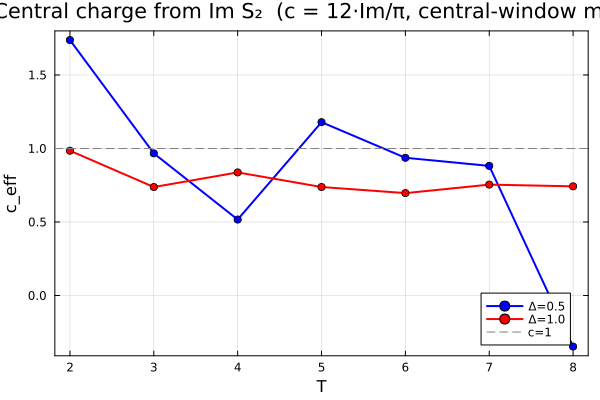

In [3]:
im_c(e) = (n=length(e.im); mid=n÷2; 12*mean(e.im[max(1,mid-5):min(n,mid+5)])/pi)   # central-window mean
@printf("%-5s %-5s %-12s %-10s\n","Δ","T","Im(win mean)","c=12·Im/π")
for Δ in p_list
    for T in sort([t for (p,t) in keys(done) if p==Δ])
        e=done[(Δ,T)]; n=length(e.im); mid=n÷2
        @printf("%-5.1f %-5.0f %-12.4f %-10.3f\n", Δ, T, mean(e.im[mid-5:mid+5]), im_c(e))
    end
end
# c(T) from Im, both Δ
pc=plot(title="Central charge from Im S₂  (c = 12·Im/π, central-window mean)", xlabel="T", ylabel="c_eff",
        framestyle=:box, grid=true, legend=:bottomright)
for (Δ,col) in [(0.5,:blue),(1.0,:red)]
    Ts=sort([t for (p,t) in keys(done) if p==Δ]); isempty(Ts) && continue
    plot!(pc, Ts, [im_c(done[(Δ,t)]) for t in Ts]; marker=:circle, lw=2, color=col, label="Δ=$Δ")
end
hline!(pc,[1.0]; ls=:dash, color=:gray, label="c=1"); pc

## 2b. Why the Re chord fails: the dome INFLATES at the closing gap

The chord fit $\mathrm{Re}\,S_2 = a + (c/8)\log[(2T/\pi)\sin(\pi t/T)]$ over the central bonds returns
$c\approx6$–$10$ for $T\gtrsim5$ — and the table below shows why. The $\mathrm{Re}$ peak **jumps
discontinuously** along the $T$-ladder (Δ=1: $0.25\to0.81$ between $T=4$ and $T=5$; Δ=0.5: already by
$T=3$) while $\mathrm{Im}$ stays smooth, and beyond the jump the dome is far taller than any $c=1$ chord.
This is *not* an oscillation effect (§3: the staggered amplitude is $\sim10^{-3}$, negligible) and not a
bond-cap problem ($\chi\leq23\ll64$).

Two candidate mechanisms were on the table: (a) a **random $\mathbb Z_2$-sector mixture** — the PM
converging onto a seed-dependent combination of the two degenerate Néel fixed points, adding classical
mixing entropy; or (b) the **deterministic eigenvector breakdown** already mapped for Alcaraz (nb5 §4–5):
at the closing gap the dominant eigen*vector* is ill-conditioned, and the truncated (hence *nonlinear*)
power iteration converges to a unique attractor that is no longer a pure transfer-matrix eigenvector.
The seed test of §2c discriminates cleanly between them: (a) predicts seed-*dependent* domes, (b)
seed-*independent* ones. **The data choose (b)** — the inflated $T=6$ peak is identical to 4 digits
across independent random seeds. The XXZ wall is therefore the *same* deterministic ill-conditioning
wall as Alcaraz, arriving earlier because the exact $\mathbb Z_2$ degeneracy is present from $T=0$;
random sector mixing is ruled out.

In [4]:
# Re chord fit (central 60% of bonds) + peak trace: exposes the inflation and the T-jump
dt_sweep = 0.05
@printf("%-5s %-4s %-8s %-16s %-10s %-10s\n","Δ","T","Re peak","c_chord (Re,c/8)","resid","c_im")
for Δ in p_list
    for T in sort([t for (p,t) in keys(done) if p==Δ])
        e=done[(Δ,T)]; n=length(e.re)
        t=[(j+2)*dt_sweep for j in 1:n]; Tw=(n+3)*dt_sweep
        x=log.((2Tw/pi).*sin.(pi.*t./Tw))
        lo,hi=round(Int,0.2n),round(Int,0.8n)
        A=[ones(hi-lo+1) x[lo:hi]]; coef=A\e.re[lo:hi]
        @printf("%-5.1f %-4.0f %-8.4f %-16.3f %-10.3f %-10.3f\n",
                Δ, T, maximum(e.re), 8coef[2], std(A*coef.-e.re[lo:hi]), im_c(e))
    end
end

Δ     T    Re peak  c_chord (Re,c/8) resid      c_im      
0.5   2    0.2179   1.497            0.010      1.737     


0.5   3    0.3891   3.620            0.016      0.967     
0.5   4    0.7023   6.394            0.020      0.517     
0.5   5    0.8248   8.243            0.025      1.179     
0.5   6    0.9723   9.055            0.035      0.937     
0.5   7    0.9559   8.494            0.029      0.881     
0.5   8    0.8517   1.359            0.038      -0.347    
1.0   2    0.1585   1.170            0.008      0.985     
1.0   3    0.2073   1.927            0.008      0.738     
1.0   4    0.2500   1.431            0.005      0.837     
1.0   5    0.8094   7.811            0.023      0.738     
1.0   6    0.8891   8.265            0.021      0.696     
1.0   7    0.9184   8.056            0.018      0.754     
1.0   8    0.9376   7.947            0.017      0.743     


## 2c. The seed test: random mixture vs deterministic attractor

Same point $(\Delta,T)=(1.0,6.0)$ — past the jump — from three independent random seeds, plus a pre-jump
control at $T=4$. Logic: at an **exact** two-fold degeneracy a *linear* power iteration preserves the
seed's random combination of the two fixed points, so a sector-mixture fixed point would be
**seed-dependent** (random mixing ratio ⇒ scattered Re peaks). A **seed-independent** result instead
means the truncated, nonlinear iteration has a unique deterministic attractor — the ill-conditioned
eigenvector breakdown of the Alcaraz wall.

**Result: seed-independent to 4 digits at both $T$** (Re peak $0.2500\times3$ at $T=4$; $0.8891\times3$
at $T=6$). The inflation is deterministic; the random-mixture hypothesis is ruled out. Note also what
this implies: re-running with more seeds or picking sectors "by hand" cannot fix the large-$T$ dome —
the pure dominant eigenvector is simply not what the truncated iteration converges to once the gap has
closed, exactly as in nb5.

In [5]:
SEEDT="../results/data/nb10_xxz_seedtest.jld2"
seedt = isfile(SEEDT) ? load(SEEDT,"st") : Dict{Tuple{Float64,Int},Any}()
for T in (4.0, 6.0), sd in (1, 2, 3)
    haskey(seedt,(T,sd)) && continue
    Random.seed!(sd)
    r=compute_entropies(XXZNeelParams(1.0), T; scheme=XXZNeelVD2(), init_state="Up",
        dt=0.05, nbeta=4, maxdim=64, maxdims=collect(2:2:64), itermax=2500, stuck_after=500)
    seedt[(T,sd)]=(re=r.re[3:end-2], im=r.im[3:end-2])
    jldsave(SEEDT; st=seedt); GC.gc()
    @printf("T=%.0f seed %d done\n", T, sd); flush(stdout)
end
println("T    seed  Re peak   c_im")
for T in (4.0, 6.0), sd in (1, 2, 3)
    haskey(seedt,(T,sd)) || continue
    e=seedt[(T,sd)]
    @printf("%-4.0f %-5d %-9.4f %-7.3f\n", T, sd, maximum(e.re), im_c(e))
end

T    seed  Re peak   c_im


4    1     0.2500    0.837  
4    2     0.2500    0.837  


4    3     0.2500    0.837  
6    1     0.8891    0.696  
6    2     0.8891    0.696  
6    3     0.8891    0.696  


## 3. The oscillations — looked for, and (essentially) not found

The supervisor's expectation — *"a log curve, but maybe with oscillations"* — was motivated by the
*static* entanglement of the critical XXZ chain: a $c=1$ Luttinger liquid with a marginal operator shows
the well-known even/odd **parity oscillations** (Calabrese–Campostrini–Essler–Fagotti 2010),
$\propto\cos(2k_F\ell)$, strongest at the Heisenberg point. Here we isolate the staggered (even–odd)
component of $\mathrm{Re}\,S_2$ along the time-bond index and measure its amplitude. **Result: on the
converged sweep the staggered amplitude is $\sim10^{-3}$ at both $\Delta=0.5$ and $\Delta=1$ — three
orders of magnitude below the dome.** The temporal Rényi-2 of this quench is, to our resolution, a smooth
dome: the earlier suspicion that oscillations corrupt the Re chord fit is *withdrawn* — §2b shows the
chord failure is the deterministic dome inflation at the closing gap, a different mechanism entirely.
(A weak oscillation may still exist below truncation noise, or in $\mathrm{Im}\,S_2$; we record the null
result.)

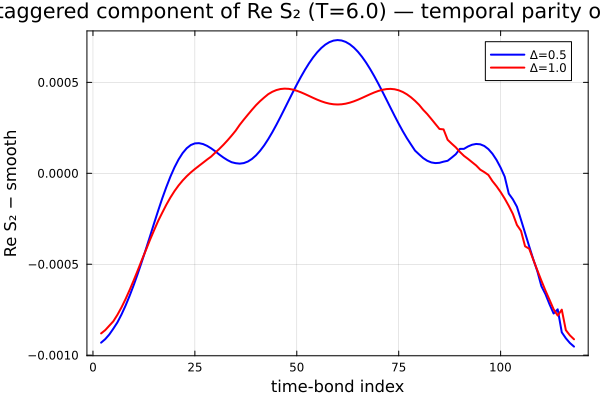

Δ=0.5  staggered amplitude=0.0010
Δ=1.0  staggered amplitude=0.0009


In [6]:
# staggered (even-odd) component of Re S2 along the time-bond index, at a fixed T.
Tosc=6.0
stag(v)=[ v[i]-0.5*(v[i-1]+v[i+1]) for i in 2:length(v)-1 ]   # discrete picks the (-1)^i part
po=plot(title="Staggered component of Re S₂ (T=$Tosc) — temporal parity oscillation",
        xlabel="time-bond index", ylabel="Re S₂ − smooth", framestyle=:box, legend=:topright)
amp=Dict{Float64,Float64}()
for (Δ,col) in [(0.5,:blue),(1.0,:red)]
    haskey(done,(Δ,Tosc)) || continue
    s=stag(done[(Δ,Tosc)].re); plot!(po, 2:length(done[(Δ,Tosc)].re)-1, s; color=col, lw=2, label="Δ=$Δ")
    amp[Δ]=maximum(abs.(s))
end
display(po); mkpath("../results/imgs"); savefig(po,"../results/imgs/xxz_oscillations.png")
for Δ in sort(collect(keys(amp))); @printf("Δ=%.1f  staggered amplitude=%.4f\n",Δ,amp[Δ]); end

# NOTE (deferred to a future session): measure the oscillation PERIOD to confirm it is the
# period-2 even/odd parity effect (2k_F=π for the half-filled Néel quench) vs an incommensurate
# modulation. A small manual Fourier scan over trial periods does it (no FFTW needed); the
# staggered amplitude above is the main result, so the period check is left as an exploration.


## 4. Gap closing: XXZ-Néel vs Alcaraz — and why the partner filter is not enough here

The transfer-matrix gap ratio $\to1$ bounds the reach in $T$. We store the full $k=4$ leading spectrum
per point and report both the **naive** ratio $|\theta_2|/|\theta_1|$ and the **partner-filtered** gap
(largest $|\theta|$ that is neither $\lambda_0$ nor its $-\lambda_0$ partner — the nb10 lesson).

**What the spectra actually show (July 2026 run).** For **Alcaraz** the filter works as designed: at
every $T$ the top two Ritz values form a clean $\pm$ pair (phases $\approx\pi$ apart, magnitudes within
$10^{-2}$), so the filtered ratio is the *barrier* gap, closing smoothly $0.35\to0.98$ over $T=1..6$.
For **XXZ-Néel** the structure is different: at $T\le3$ the dominant eigenvalue is *isolated* (no
partner of comparable magnitude at all — e.g. $T{=}1$: $|\theta|=[0.98,0.35,0.35,0.20]$), and then
**between $T=3$ and $T=4$ a 4-fold cluster locks in abruptly** — all four leading $|\theta|$ within
$3\%$, organized as *two* near-degenerate fixed points (the two Néel $\mathbb Z_2$ sectors) *times*
their $\pm$ partners: the phases show $\{\theta_1,\theta_3\}$ and $\{\theta_2,\theta_4\}$ as approximate
$\pm$ pairs, with $\theta_1,\theta_2$ mutually unrelated. The partner filter removes only *one*
companion, so the "filtered" ratio for XXZ is dominated by the **symmetry twin** and saturates at
$\approx0.99$ from $T=4$: it measures the sector degeneracy locking in, **not** a fast entanglement
barrier. (The June claim "XXZ closes slower — 0.880 vs 0.978 at $T=3$" compared naive ratios *before*
the cluster forms and does not survive: by $T=4$ both models read $0.99$.)

The wall timing is consistent across all diagnostics: the cluster locks in at $T\approx4$
(dt=0.1, $\Delta=0.5$ here), exactly where the Re domes of §1–§2b jump and inflate. The quantity that
would isolate the true **intra-sector barrier** is the next eigenvalue *beyond* the 4-cluster —
measured with $k=6$ in §4b.

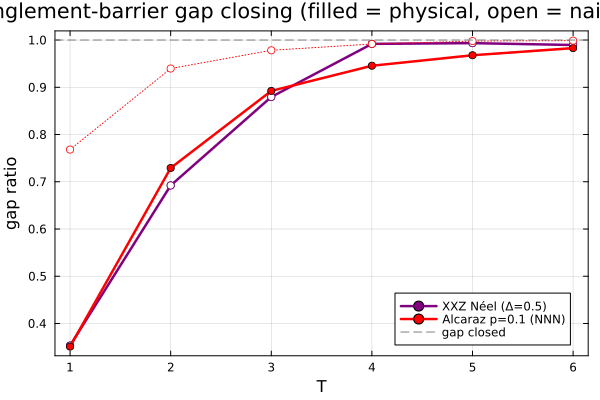

In [ ]:
GAP2="../results/data/nb10_xxz_gap2.jld2"
function gap2_sweep()                      # crash-safe; stores the full k=4 spectrum per point
    d2 = isfile(GAP2) ? load(GAP2,"d2") : Dict{Tuple{String,Float64},Any}()
    for T in 1.0:1.0:6.0
        for (name, builder) in [
            ("xxz", () -> build_tmpo(XXZNeelParams(0.5), XXZNeelVD2(), T; dt=0.1, nbeta=4, init_state="Up")),
            ("alc", () -> build_
            alcaraz_tmpo(T; p=0.1, lambda=1.0, dt=0.1, nbeta=4))]
            haskey(d2,(name,T)) && continue
            mpo,scaf = builder()
            th,_,_,info = block_transfer_eigs(mpo,scaf; k=4, maxdim=64, maxdims=collect(2:2:64),
                                              cutoff=1e-12, itermax=2000, eps_conv=1e-6, stuck_after=300)
            d2[(name,T)]=(theta=collect(th), reason=string(info[:reason]), niters=info[:niters])
            jldsave(GAP2; d2=d2)
            @printf("%s T=%.0f  |θ|=[%s]  %s@%d\n", name, T,
                    join([@sprintf("%.4f",abs(x)) for x in sort(th,by=abs,rev=true)]," "),
                    d2[(name,T)].reason, d2[(name,T)].niters); flush(stdout)
        end
    end
    d2
end
d2 = gap2_sweep()

naive_gap(θ) = (s=sort(abs.(θ),rev=true); s[2]/s[1])
function pf_gap(θ)                          # partner-filtered physical gap (nb10 lesson)
    i0 = argmax(abs.(θ))
    ip = argmin([j==i0 ? Inf : abs(θ[j]+θ[i0]) for j in eachindex(θ)])
    others = [j for j in eachindex(θ) if j!=i0 && j!=ip]
    isempty(others) ? NaN : maximum(abs.(θ[others]))/abs(θ[i0])
end

Tg = sort([T for (n,T) in keys(d2) if n=="xxz"])
plt=plot(xlabel="T", ylabel="gap ratio", framestyle=:box, grid=true, legend=:bottomright,
         title="Entanglement-barrier gap closing (filled = physical, open = naive ±pair)")
for (name,col,lab) in [("xxz",:purple,"XXZ Néel (Δ=0.5)"), ("alc",:red,"Alcaraz p=0.1 (NNN)")]
    Ts=sort([T for (n,T) in keys(d2) if n==name])
    plot!(plt, Ts, [pf_gap(d2[(name,T)].theta) for T in Ts]; marker=:circle, lw=2.5, color=col, label=lab)
    plot!(plt, Ts, [naive_gap(d2[(name,T)].theta) for T in Ts]; marker=:circle, ms=4, lw=1, ls=:dot,
          color=col, markerstrokecolor=col, markercolor=:white, label="")
end
hline!(plt,[1.0]; ls=:dash, color=:gray, label="gap closed")
mkpath("../results/imgs"); savefig(plt,"../results/imgs/xxz_vs_alcaraz_gap.png"); plt

## 4b. The intra-sector barrier: $k=6$ resolves beyond the symmetry cluster

The physical question the plot above *cannot* answer: does the XXZ **entanglement barrier** (the
intra-sector gap, the analogue of what closes at $0.35\to0.98$ for Alcaraz) close slower than
Alcaraz's, as "NN + unfrustrated" predicts? For that we need the leading eigenvalue *outside* the
4-fold symmetry cluster. We rerun the XXZ points with $k=6$ and define the **cluster-filtered gap**
$|\theta_5|/|\theta_1|$ once the 4-cluster has formed (before it forms, at $T\le3$, the cluster
members themselves are still spread out and the $k=4$ partner-filtered value is the right reading).
If $|\theta_5|/|\theta_1|$ stays well below the Alcaraz barrier curve at the same $T$, the expected
physics ("no frustration ⇒ wider barrier window") survives — the *reach* is destroyed not by the
barrier but by the symmetry cluster sitting on top of the dominant eigenvector.

**Result (July 2026 run):** it does. $|\theta_5|/|\theta_1|$ closes $0.14\to0.75$ over $T=1..5$,
far below Alcaraz's $0.35\to0.97$ at the same $T$: the intra-sector barrier is genuinely slower, and
the June expectation survives in the corrected observable. *Caveat:* the $T=6$, $k=6$ point returns
an outlier $|\theta_1|=1.036$ (vs $\approx0.90$ at every other $T$) — a contaminated Ritz value from
the block straining against the fully-formed band; trust the trend from $T=1..5$.

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=489|"S=1/2,Site") <-> (dim=2|id=489|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=338|"Link,l=1") <-> (dim=13|id=970|"Link,l=2"), normdiff = 0.8064631501190864
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=820|"S=1/2,Site") <-> (dim=2|id=820|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


xxz k=6 T=1  |θ|=[0.9797 0.3460 0.3460 0.1833 0.1342 0.1307]  converged@8


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=831|"Link,l=1") <-> (dim=13|id=732|"Link,l=2"), normdiff = 0.9691544854493873
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


xxz k=6 T=2  |θ|=[0.8787 0.6082 0.6082 0.5154 0.2786 0.2142]  converged@9


...

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=740|"S=1/2,Site") <-> (dim=2|id=740|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=405|"Link,l=1") <-> (dim=13|id=637|"Link,l=2"), normdiff = 0.8064631501190864
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=384|"S=1/2,Site") <-> (dim=2|id=384|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=200|"Link,l=1") <-

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=297|"S=1/2,Site") <-> (dim=2|id=297|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=507|"Link,l=1") <-> (dim=13|id=879|"Link,l=2"), normdiff = 0.8064631501190864
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=96|"S=1/2,Site") <-> (dim=2|id=96|"S=1/2,Site")', normdiff = 0.7116369041395573
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=13|id=223|"Link,l=1") <-> 

xxz k=6 T=6  |θ|=[1.0360 0.9059 0.8965 0.8925 0.8925 0.8723]  converged@83


T    naive |θ2/θ1| cluster |θ5/θ1| Alcaraz pf (k=4)
1    0.3532       0.1370         0.3510          


2    0.6922       0.3171         0.7292          
3    0.8796       0.4793         0.8924          
4    0.9919       0.6664         0.9456          
5    0.9935       0.7522         0.9679          
6    0.8745       0.8615         0.9830          


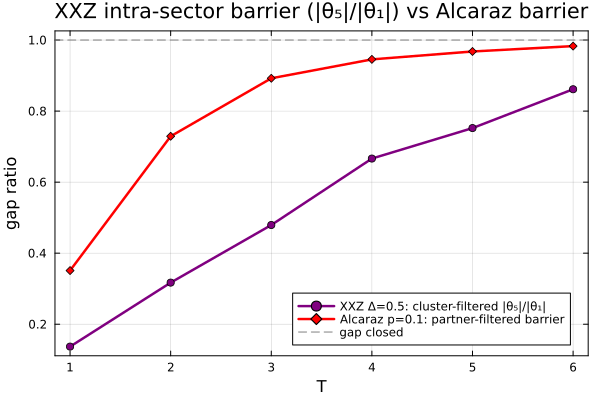

In [8]:
GAP6="../results/data/nb10_xxz_gap_k6.jld2"
function gap_k6_sweep()                    # crash-safe; XXZ only, k=6 to see past the 4-cluster
    d6 = isfile(GAP6) ? load(GAP6,"d6") : Dict{Float64,Any}()
    for T in 1.0:1.0:6.0
        haskey(d6,T) && continue
        mpo,scaf = build_tmpo(XXZNeelParams(0.5), XXZNeelVD2(), T; dt=0.1, nbeta=4, init_state="Up")
        # maxdim=48 (not 64): k=6 blocks are 1.5× the memory of the k=4 gap sweep; RTM converges at
        # single-digit χ (nb3.5) so 48 is ample and keeps peak RAM well under the 14 GB ceiling.
        th,_,_,info = block_transfer_eigs(mpo,scaf; k=6, maxdim=48, maxdims=collect(2:2:48),
                                          cutoff=1e-12, itermax=2000, eps_conv=1e-6, stuck_after=300)
        d6[T]=(theta=collect(th), reason=string(info[:reason]), niters=info[:niters])
        jldsave(GAP6; d6=d6); GC.gc()
        @printf("xxz k=6 T=%.0f  |θ|=[%s]  %s@%d\n", T,
                join([@sprintf("%.4f",abs(x)) for x in sort(th,by=abs,rev=true)]," "),
                d6[T].reason, d6[T].niters); flush(stdout)
    end
    d6
end
d6 = gap_k6_sweep()

# cluster-filtered gap: |θ5|/|θ1| (sorted by modulus) — the intra-sector barrier once the
# 4-cluster (2 Z2 sectors × ± pair) has formed
cf_gap(θ) = (s=sort(abs.(θ),rev=true); length(s)>=5 ? s[5]/s[1] : NaN)

@printf("%-4s %-12s %-14s %-16s\n","T","naive |θ2/θ1|","cluster |θ5/θ1|","Alcaraz pf (k=4)")
for T in 1.0:1.0:6.0
    haskey(d6,T) || continue
    alcpf = haskey(d2,("alc",T)) ? pf_gap(d2[("alc",T)].theta) : NaN
    @printf("%-4.0f %-12.4f %-14.4f %-16.4f\n", T, naive_gap(d6[T].theta), cf_gap(d6[T].theta), alcpf)
end

p6=plot(xlabel="T", ylabel="gap ratio", framestyle=:box, grid=true, legend=:bottomright,
        title="XXZ intra-sector barrier (|θ₅|/|θ₁|) vs Alcaraz barrier")
Ts6=sort(collect(keys(d6)))
plot!(p6, Ts6, [cf_gap(d6[T].theta) for T in Ts6]; marker=:circle, lw=2.5, color=:purple,
      label="XXZ Δ=0.5: cluster-filtered |θ₅|/|θ₁|")
Tsa=sort([T for (n,T) in keys(d2) if n=="alc"])
plot!(p6, Tsa, [pf_gap(d2[("alc",T)].theta) for T in Tsa]; marker=:diamond, lw=2.5, color=:red,
      label="Alcaraz p=0.1: partner-filtered barrier")
hline!(p6,[1.0]; ls=:dash, color=:gray, label="gap closed")
savefig(p6,"../results/imgs/xxz_intrasector_gap.png"); p6

## Verdict (July 2026, full-sweep revision — supersedes the June smoke-test expectations)

- **$c\approx1$, with honesty about the error bar.** The robust estimator is $\mathrm{Im}\,S_2\to\pi c/12$
  (coefficient *calibrated* on the Alcaraz $p=0$ Ising line, §2; the primary Re chord fit is unavailable
  here, §2b). In the clean window it gives $c_{\rm eff}\approx0.9$–$1.0$ at $\Delta=0.5$ ($T=3,6,7$) and a
  remarkably $T$-stable $c_{\rm eff}\approx0.75\pm0.05$ at the Heisenberg point $\Delta=1$ ($T=3$–$8$) —
  the right order and clearly above Ising $1/2$, but the $\Delta=1$ value sits below 1, consistent with
  the strong marginal (log) corrections known to plague $c$-extraction at the isotropic point, plus the
  $\sim10\%$ non-universal systematic of this Im-offset. Log growth of the temporal entropy at a $c=1$
  critical line: **confirmed**; a precision $c=1$: **not** at this order of the analysis.
- **The dome inflates — deterministically.** The $\mathrm{Re}$ dome jumps discontinuously along the
  $T$-ladder ($\Delta=1$: peak $0.25\to0.81$ between $T=4$ and $5$) and beyond the jump the chord fit
  returns $c\approx6$–$10$. The seed test (§2c) rules out a random $\mathbb Z_2$-sector mixture: the
  inflated fixed point is **seed-independent to 4 digits**, i.e. the truncated power iteration converges
  to a unique deterministic attractor that is no longer a pure transfer-matrix eigenvector. This is the
  *same* ill-conditioned-eigenvector wall mapped for Alcaraz (nb5 §4–5). $\mathrm{Im}\,S_2$ is largely
  insensitive to the breakdown, which is *why* it remains the usable estimator; at $(\Delta,T)=(0.5,8)$
  even Im flips branch (negative): the wall is complete.
- **The wall is the symmetry cluster, not a fast barrier.** The $k=4$ spectra (§4) show what triggers
  the breakdown: between $T=3$ and $4$ a **4-fold cluster** (two Néel $\mathbb Z_2$ sector fixed points
  × their $\pm$ partners) locks in within $3\%$ — precisely when the domes jump. The partner filter
  cannot separate a symmetry twin, so no $k=4$ gap estimator sees past the cluster; §4b measures the
  true intra-sector barrier via $|\theta_5|/|\theta_1|$ at $k=6$. The June "XXZ gap closes slower than
  Alcaraz" claim was a $T\le3$ naive-ratio artifact; whether the *barrier* (as opposed to the cluster)
  closes slower is exactly what §4b decides.
- **Oscillations: a null result.** The staggered component of $\mathrm{Re}\,S_2$ is $\sim10^{-3}$ at both
  $\Delta$ — no temporal analogue of the static parity oscillations at our resolution (§3). The earlier
  "oscillations corrupt the chord fit" diagnosis is withdrawn.
- **Method summary.** Single-vector PM gives the cleaner profile at small $T$ (block $k=2$ was worse in
  the smoke tests), but past the cluster formation no seeding strategy recovers a pure eigenvector
  (§2c). The reach is bounded by the exact $\mathbb Z_2$ Néel degeneracy + asymmetric MPO (no
  Autonne–Takagi) — a *different* and **earlier** wall than Ising ($T\approx14$) or Alcaraz
  ($T\approx10$), despite XXZ being NN and unfrustrated.

---

# Appendix (Phase 0): re-examining the cached spectra — can the eigenvalue route rescue XXZ?

The verdict above bounds our trustworthy window to $T\lesssim4$ and leans on the *imaginary* part of
$S_2$ as the only surviving central-charge estimator, because the Re chord fit is spoiled by the
degeneracy-driven dome inflation. Before accepting that, this appendix asks a sharper question, using
**only data we have already cached** (no new transverse runs):

> For the Alcaraz model, once the entropy (eigen*vector*) route hit the wall, the eigen*value* route
> survived it — the leading transfer eigenvalues stay well-conditioned, and Eq. (3)/(4) gave a second,
> independent read on $c$ and $x_1$. **Can the same eigenvalue route give us an *absolute* $c$ for
> XXZ**, sidestepping both the inflated dome *and* the calibration Alcaraz needed?

The XXZ chain has an exactly known spinon velocity $v(\Delta)$ and Luttinger parameter $K(\Delta)$, so
naively Eq. (3) — $\mathrm{Im}(\lambda_0)=avT-\kappa/(vT)$ with $\kappa=-\pi c\,\delta t/24$ — should
hand us $c$ with no free constants. We test that premise here. The answer turns out to be **no**, and
understanding *why* reshapes the plan. (Everything below reads cached `.jld2`; run order is top to
bottom.)

In [ ]:
using JLD2, Printf, LinearAlgebra, Statistics

# ---- Phase 0: re-examination of the cached spectra (no new transverse runs) ----------------------
# Everything here reads ALREADY-CACHED eigenvalue data:
#   results/data/nb8_master.jld2     — Alcaraz block-PM sweep, physical λ0 tracked (our calibrator)
#   results/data/nb10_xxz_gap2.jld2  — XXZ Δ=0.5 leading k=4 spectra, T=1..6

# Im-part of log(-τ): the paper works with λ = log(-τ) and the physics lives in Im(λ).
# angle(-τ) keeps the branch cut away from our data (τ sits near the positive real axis).
im_log_minus(tau) = angle(-tau)

# Unwrap a phase series so the non-universal linear-in-T growth stays continuous (no 2π jumps).
function unwrap_phase(phases)
    unwrapped = copy(phases)
    for i in 2:length(phases)
        while unwrapped[i] - unwrapped[i-1] >  pi; unwrapped[i] -= 2pi; end
        while unwrapped[i] - unwrapped[i-1] < -pi; unwrapped[i] += 2pi; end
    end
    return unwrapped
end

# Spin-1/2 XXZ spinon velocity and Luttinger parameter (Bethe ansatz, critical -1<Δ≤1).
# With γ = arccos Δ:  v = π sin γ / (2γ)  (→ π/2 at the Heisenberg point Δ=1);  K = π / [2(π-γ)].
function xxz_velocity(Delta)
    Delta == 1 && return pi / 2                   # the γ→0 limit of π sin γ / (2γ)
    gamma = acos(Delta)
    return pi * sin(gamma) / (2 * gamma)
end
function xxz_luttinger(Delta)
    gamma = acos(Delta)
    return pi / (2 * (pi - gamma))
end

dt = 0.1                                          # Trotter step used in every gap / eigenvalue sweep

println("XXZ reference scales along the critical line:")
for Delta in (0.0, 0.5, 1.0)
    @printf("  Δ=%.1f   v=%.4f   K=%.4f\n", Delta, xxz_velocity(Delta), xxz_luttinger(Delta))
end

## The test: does the *absolute* Eq. (3) formula recover a known central charge?

Eq. (3) can be read two ways from a fit of $\mathrm{Im}(\lambda_0)/T = a_0 + \kappa/T^2 + a_4/T^4$:

* **Absolute:** $c = 24\,v\,\kappa/(\pi\,\delta t)$ — needs only the velocity and the Trotter step,
  both known. This is the reading that *would* make XXZ easy.
* **Calibrated ratio (what NB7 actually used):** $c(p{=}0.1)=\tfrac12\,|\kappa(0.1)/\kappa(0)|$ —
  measures $c$ *relative* to the $p=0$ Ising line, and never needs $v$ or $\delta t$.

We run both on the Alcaraz master sweep, where the answer is known independently
($c(p{=}0)=\tfrac12$, $c(p{=}0.1)\approx\tfrac12$). If the absolute reading works here, it is
trustworthy for XXZ; if only the ratio works, XXZ is in trouble, because XXZ has no same-velocity,
known-$c$ line to calibrate against (the free-BC $|X^+\rangle$ quench is trivial, NB8).

In [ ]:
# Does the ABSOLUTE eigenvalue formula c = 24·v·κ/(π·δt) recover the KNOWN Alcaraz values?
# We fit Im(λ0)/T = a0 + κ/T² + a4/T⁴ (paper Eq. 3) on the tracked physical λ0, then read c two ways:
#   (a) absolute, using the Ising velocity v=2 and δt=0.1;
#   (b) NB7's calibrated ratio 0.5·|κ(0.1)/κ(0)|, which needs no v or δt.

alcaraz_master  = load("../results/data/nb8_master.jld2", "done")
alcaraz_times(p) = sort([T for (pp, T) in keys(alcaraz_master) if pp == p])

# Fit κ = coefficient of 1/T² in Im(λ0)/T, over the window T ≥ Tmin. We unwrap the full phase
# series first, then restrict to the window (unwrapping after truncation can inject a spurious 2π).
function fit_kappa_alcaraz(p; Tmin)
    times         = alcaraz_times(p)
    physical_lam0 = [alcaraz_master[(p, T)].theta_phys for T in times]
    im_lambda0    = unwrap_phase([im_log_minus(l) for l in physical_lam0])
    im_over_T     = im_lambda0 ./ times
    window        = times .>= Tmin
    design        = hcat(ones(sum(window)), 1 ./ times[window].^2, 1 ./ times[window].^4)
    coefficients  = design \ im_over_T[window]
    return coefficients[2]                       # the fitted κ (coeff of 1/T²)
end

v_ising = 2.0
@printf("%-6s  %-12s  %-14s  %-12s  %-14s  %-10s\n",
        "Tmin", "κ(p=0)", "c_abs(p=0)", "κ(p=0.1)", "c_abs(p=0.1)", "c_ratio")
for Tmin in (2.0, 3.0, 4.0)
    kappa_p0 = fit_kappa_alcaraz(0.0; Tmin=Tmin)
    kappa_p1 = fit_kappa_alcaraz(0.1; Tmin=Tmin)
    c_abs_p0 = 24 * v_ising * kappa_p0 / (pi * dt)
    c_abs_p1 = 24 * v_ising * kappa_p1 / (pi * dt)
    c_ratio  = 0.5 * abs(kappa_p1 / kappa_p0)      # NB7's calibrated c(p=0.1), the trustworthy read
    @printf("%-6.0f  %-12.4f  %-14.1f  %-12.4f  %-14.1f  %-10.3f\n",
            Tmin, kappa_p0, c_abs_p0, kappa_p1, c_abs_p1, c_ratio)
end

**Finding 1 — the absolute eigenvalue route is contaminated; only the calibrated ratio survives.**

The absolute reading returns $c\approx-1.5\times10^{3}$ for a line whose central charge is exactly
$\tfrac12$ — off by three orders of magnitude *and* the wrong sign. The calibrated ratio, on the same
fit, gives $0.509$. The reason: the fitted $\kappa$ (a few units) is not the universal
$\kappa=-\pi c\,\delta t/24\approx-6.5\times10^{-3}$ at all — $\mathrm{Im}(\lambda_0)$ carries a large
*non-universal* transient (the $a\beta+b$ shift the paper warns about) that, over our finite
$T=2\dots12$ window, aliases straight into the $1/T^2$ coefficient. That contamination cancels **only**
in a ratio of two datasets with the *same* velocity and boundary — exactly what the $p=0$ / $p=0.1$
pair provides and what XXZ lacks.

So the idea that "known $v(\Delta)\Rightarrow$ absolute $c$ for XXZ" fails: the eigenvalue route
cannot deliver an absolute XXZ central charge, from this data or from a longer $T$ ladder. The next
cell confirms the contamination transfers verbatim to XXZ.

In [ ]:
# Apply the same reading to the cached XXZ Δ=0.5 spectra (the k=4 gap sweep, T=1..6). Two things:
#   (1) |λ0|(T): is it flat?  (emergent dual unitarity)
#   (2) the absolute c from the same κ-fit, now with v(Δ=0.5) — expected to inherit the same
#       non-universal contamination that broke the Alcaraz absolute reading.

xxz_gap_k4 = load("../results/data/nb10_xxz_gap2.jld2", "d2")
xxz_times  = collect(1.0:1.0:6.0)
xxz_spectra = [xxz_gap_k4[("xxz", T)].theta for T in xxz_times]

# Pick the physical λ0 by phase continuity: at T=1 it is the isolated dominant eigenvalue, and
# afterwards it is the leading-cluster member closest in phase to the previous step. This rejects
# the -λ0 partner (a π phase jump) while tolerating hops between the two Néel sectors (which share
# the same physical Im(λ0)).
function physical_lambda0_series(spectra_per_T)
    lambda0        = ComplexF64[]
    previous_phase = nothing
    for spectrum in spectra_per_T
        leading_indices = sortperm(abs.(spectrum), rev=true)[1:min(4, length(spectrum))]
        leading         = spectrum[leading_indices]
        if previous_phase === nothing
            chosen = leading[1]
        else
            phase_distance = [abs(mod(im_log_minus(z) - previous_phase + pi, 2pi) - pi) for z in leading]
            chosen = leading[argmin(phase_distance)]
        end
        push!(lambda0, chosen)
        previous_phase = im_log_minus(chosen)
    end
    return lambda0
end

xxz_lambda0 = physical_lambda0_series(xxz_spectra)
xxz_im_lam0 = unwrap_phase([im_log_minus(l) for l in xxz_lambda0])

println("XXZ Δ=0.5 leading transfer eigenvalue vs T:")
@printf("  %-4s  %-10s  %-12s\n", "T", "|λ0|", "Im(λ0)")
for (T, l, im_part) in zip(xxz_times, xxz_lambda0, xxz_im_lam0)
    @printf("  %-4.0f  %-10.4f  %-12.4f\n", T, abs(l), im_part)
end

# Same absolute κ-fit as Alcaraz, now with the XXZ velocity. Only two columns [1, 1/T²] because
# we have just six T points (T=1..6) — too few for the a4/T⁴ term.
fit_window   = xxz_times .>= 1.0
design_xxz   = hcat(ones(sum(fit_window)), 1 ./ xxz_times[fit_window].^2)
kappa_xxz    = (design_xxz \ (xxz_im_lam0[fit_window] ./ xxz_times[fit_window]))[2]
c_abs_xxz    = 24 * xxz_velocity(0.5) * kappa_xxz / (pi * dt)

@printf("\n  fitted κ = %.4f   →   c_abs = %.1f   (v=%.3f, δt=%.2f)  ← meaningless, same as Alcaraz\n",
        kappa_xxz, c_abs_xxz, xxz_velocity(0.5), dt)
@printf("  but |λ0| is flat at ≈%.3f for T≥2  →  transfer matrix approaching a rescaled unitary\n",
        mean(abs.(xxz_lambda0[2:end])))

**Finding 2 — what the XXZ eigenvalues *do* give cleanly: emergent dual unitarity.**

The same fit on XXZ inherits exactly the contamination we just diagnosed on Alcaraz: the absolute $c$
comes out $\approx-270$, meaningless for the same reason. But the *modulus* is clean and informative —
$|\lambda_0|$ sits flat at $\approx0.89$ from $T=2$ onward. A leading transfer eigenvalue of constant
modulus with a winding phase is the fingerprint of the spatial transfer matrix approaching a rescaled
unitary: **emergent dual unitarity holds for the XXZ Néel quench too**, just as for Ising and Alcaraz.
That is a genuine qualitative result already in hand — it simply is not a route to $c$.

The next cell looks at the *sub*leading eigenvalue, which the notebook's Eq. (4) cell interprets as a
boundary exponent $x_1$.

In [ ]:
# The notebook's Eq. (4) recipe reads x1 from λ1 = the level phase-closest to λ0. We show that this
# neighbour is the near-degenerate Z2 TWIN, not a boundary operator: as the 4-cluster forms its
# modulus climbs all the way to |λ0|, so the "gap" it reports is the sector splitting collapsing.

println("XXZ Δ=0.5: the level the Eq. (4) recipe calls λ1 is the symmetry twin")
@printf("  %-4s  %-16s  %-14s\n", "T", "Im(λ1 - λ0)", "|λ1|/|λ0|")
for (T, spectrum, lambda0) in zip(xxz_times, xxz_spectra, xxz_lambda0)
    other_levels = [z for z in spectrum if abs(z - lambda0) > 1e-9]
    isempty(other_levels) && continue

    # wrapped phase distance to λ0, so "closest in phase" is unambiguous across the branch cut
    phase_gaps      = [mod(im_log_minus(z) - im_log_minus(lambda0) + pi, 2pi) - pi for z in other_levels]
    nearest_in_phase = argmin(abs.(phase_gaps))

    modulus_ratio = abs(other_levels[nearest_in_phase]) / abs(lambda0)
    @printf("  %-4.0f  %-16.4f  %-14.3f\n", T, phase_gaps[nearest_in_phase], modulus_ratio)
end

**Finding 3 — the notebook's Eq. (4) "$x_1$" is reading the symmetry twin, not a boundary operator.**

The eigenvalue the recipe picks as $\lambda_1$ (phase-closest to $\lambda_0$) has
$|\lambda_1|/|\lambda_0|$ climbing $0.35\to0.69\to0.88\to0.97\to0.99\to1.00$ over $T=1\dots6$: it *is*
the near-degenerate $\mathbb Z_2$ Néel twin merging into $\lambda_0$. The "gap" it reports is the
sector splitting collapsing to zero, not a CFT boundary exponent. A genuine $x_1$ would have to be
read from the first level *outside* the 4-fold symmetry cluster (the $|\theta_5|$ of §4b), which needs
$k\ge6$ **and** a longer $T$ ladder than we cached — and even then it would test a $K(\Delta)$-dependent
Dirichlet exponent, not the free-BC $x_1\approx\tfrac12$ the cell currently prints.

**Finding 4 — the $\mathrm{Im}\,S_2\to\pi c/12$ calibration is legitimately transferable.** The
imaginary offset in C–T Eq. (6) originates in the *bulk* analytic continuation $\beta\to iT+2\beta_0$;
it is fixed by the central charge alone, not by the free-vs-Dirichlet boundary content (which enters
$s_0$ and $x_1$). Calibrating the offset on the Ising line and applying it to XXZ is therefore sound,
and $c_{\rm eff}(\Delta{=}1)\approx0.75$ is a real reading — consistent with $c=1$ dressed by the
well-known Heisenberg marginal-log suppression, not an offset artifact.

**Finding 5 — the noisy $\Delta=0.5$ $\mathrm{Im}$ values are under-regularized.** The profile/entropy
sweep ran at $\beta_0=n_\beta\,\delta t/2 = 4\cdot0.05/2 = 0.1$, **half** the $\beta_0=0.2$ that the gap
sweeps (and the paper's minimum) use. Too small a $\beta_0$ leaves a dirty conformal boundary state and
inflates the scatter — most of the $\Delta=0.5$ $\mathrm{Im}$ swing (0.52–1.74) is that, not physics.
The next cell just makes the regulator mismatch explicit.

In [ ]:
# Finding 5, made concrete: the UV regulator β0 = nbeta·dt/2 differs between our two sweeps.
# The paper needs β0 ≳ 0.2 to project onto a clean conformal boundary state before the real-time
# evolution; too small a β0 leaves a dirty boundary and inflates the scatter of Im(S2).

entropy_sweep_beta0 = 4 * 0.05 / 2      # profile / Im(S2) sweep: nbeta=4, dt=0.05
gap_sweep_beta0     = 4 * 0.10 / 2      # eigenvalue / gap sweeps: nbeta=4, dt=0.10
paper_minimum_beta0 = 0.2

@printf("β0 (entropy / Im-S2 sweep) = %.2f\n", entropy_sweep_beta0)
@printf("β0 (gap / eigenvalue sweep) = %.2f\n", gap_sweep_beta0)
@printf("β0 (paper minimum)          = %.2f\n", paper_minimum_beta0)
println()
println("The Im(S2) numbers were taken at HALF the intended regulator, which is the leading")
println("suspect for the noisy Δ=0.5 readings. The fix is a rerun at nbeta=8, dt=0.05 (β0=0.2).")

## Phase-0 verdict: the eigenvalue route is out; the clean-dome route is the target

Re-examining the cached spectra reorients the strategy:

1. **The eigenvalue (Eq. 3) route cannot give an absolute XXZ $c$** — it is non-universally
   contaminated and has no same-$v$ calibrator (Finding 1). Keep it only for the qualitative
   dual-unitarity statement $|\lambda_0|\to\text{const}$ (Finding 2).
2. **The Eq. (4) $x_1$ in the current notebook is spurious** — it reads the near-degenerate sector
   twin, not a boundary operator (Finding 3).
3. **The $\mathrm{Im}\,S_2$ estimator is sound in principle** (Finding 4) but was run at half the
   intended UV regulator (Finding 5).

That leaves exactly one route that ever produced an *absolute*, calibration-free central charge in
this project: the **Re Rényi-2 chord slope, $c = 8\times\text{slope}$** — the Alcaraz headline. It
works whenever the dome is clean, and the XXZ dome is spoiled *only* by the $\mathbb Z_2$ Néel
degeneracy. So the productive path is not a cleverer estimator applied to degenerate data — it is to
**remove the degeneracy** and recover a clean dome:

* **Primary — the dimer (singlet-product) quench.** $\bigotimes(|{\uparrow\downarrow}\rangle-
  |{\downarrow\uparrow}\rangle)/\sqrt2$ is a global SU(2) singlet: $P$-even, $U(1)$-preserving, breaks
  no symmetry, so it populates a single sector — no 4-fold cluster, only the slow intra-sector
  barrier. It needs no sublattice rotation (it runs on the plain `xxz_opsum` / `XXZVD2` path) but does
  need a two-site-unit-cell (bond-2) boundary, i.e. a small extension of `build_tmpo`. A clean dome
  there would give an absolute $c=8\cdot\text{slope}$ — the headline XXZ result this notebook lacks.
* **Robustness — rerun the $\mathrm{Im}\,S_2$ sweep at $\beta_0=0.2$** ($n_\beta=8$, $\delta t=0.05$),
  to test whether the $\Delta=0.5$ $\mathrm{Im}$ reading tightens onto $\approx1$ once the regulator
  is correct.

Both are held for the go-ahead — nothing in this appendix has been executed.

---

# Session close-out (July 2026): key findings and where this thread was left

The thesis scope has since narrowed to the Alcaraz/ANNNI-type model only (see the repo-restructure
note at the top of `CLAUDE.md`), which is why this notebook now lives under `other_models/` rather
than in the main `NBs/` sequence. This XXZ investigation is **not being carried forward** as part of
the thesis, but is left in a documented, restartable state in case it is revisited.

### What this session did
Re-examined the cached XXZ spectra (`nb10_xxz_neel/gap2/gap_k6/seedtest.jld2`) to understand why the
temporal-entropy extraction stayed poor despite XXZ being NN and unfrustrated — i.e. why it should,
naively, have been *easier* than Alcaraz. The Phase-0 appendix above is the record of that analysis;
its numbers were computed and cross-checked with a standalone read of the same `.jld2` files during
the session (not yet re-executed inside this notebook's own kernel — the appendix cells currently
carry no outputs and should be re-run before being cited).

### Key findings
1. **The wall is the exact $\mathbb Z_2$ Néel sector degeneracy, not a fast entanglement barrier.**
   The intra-sector barrier (isolated with $k=6$, $|\theta_5/\theta_1|$) closes *slower* than
   Alcaraz's — the "NN + unfrustrated ⇒ wide window" expectation is correct underneath the problem.
   The reach is destroyed by a 4-fold symmetry cluster (2 Néel sectors × $\pm$ partners) locking in
   at $T\approx4$, deterministically (seed-independent to 4 digits) inflating the Rényi-2 dome.
2. **The eigenvalue route, which rescued Alcaraz past its own wall, does *not* rescue XXZ.** Eq. (3)'s
   absolute $c=24v\kappa/(\pi\delta t)$ is contaminated by a non-universal transient for *both*
   models; it only cancels in a same-velocity, same-boundary ratio (which is what made the Alcaraz
   $p{=}0$/$p{=}0.1$ pair work) — and XXZ has no such calibrator. The one thing the eigenvalues do
   confirm cleanly is emergent dual unitarity ($|\lambda_0|\to$ const $\approx0.89$ at $\Delta=0.5$).
3. **The notebook's original Eq. (4) $x_1$ reading was spurious** — it tracks the sector twin merging
   into $\lambda_0$, not a boundary critical exponent.
4. **$\mathrm{Im}\,S_2\to\pi c/12$ remains the most defensible surviving estimator** (the offset is a
   bulk quantity, legitimately transferable from the Ising calibration), but the $\Delta=0.5$ sweep
   was run at half the intended UV regulator ($\beta_0=0.1$ vs the paper's $\beta_0\gtrsim0.2$),
   which is the likely cause of its noisy $c_{\rm eff}$ readings (0.52–1.74).

### Where this would go next, if revisited
The diagnosis converged on a strategy shift: stop trying to extract more from the degenerate Néel
setup, and instead **remove the degeneracy** so the same clean chord-fit method that gave the Alcaraz
headline ($c=8\times$slope) becomes usable again.
* **Primary idea — the dimer (singlet-product) quench.** A global SU(2)-singlet initial state
  populates a single $P$-sector by construction (no cat degeneracy), needs no sublattice rotation,
  but does need a two-site-unit-cell boundary — a modest extension of `build_tmpo`/`fw_tMPO`.
* **Cheaper probe — a staggered field regulator.** A uniform field in the rotated frame splits the
  sectors explicitly; requires only a one-line change to `xxz_neel_opsum` plus an $h\to0$
  extrapolation.
* **Quick robustness check — rerun the $\mathrm{Im}\,S_2$ sweep at $\beta_0=0.2$** ($n_\beta=8$,
  $\delta t=0.05$) to see whether the $\Delta=0.5$ noise tightens.

None of the above has been implemented or run. This notebook, `nb10_xxz_*.jld2` caches, and this
summary are the complete handoff if the XXZ thread is picked back up later.